# DQN for Capacitor Switching in a Toy Distribution Network

本 notebook 使用 DQN 在一个三节点径向配电网中学习并联电容器投切策略。
目标是验证 DQN 与 pandapower 潮流环境的交互流程，而不是追求工程级最优控制。

## 1. Experiment Setup

### 1.1 Imports

In [1]:
# 导入必要的库
import random
import copy
import collections
from collections import Counter
from dataclasses import dataclass
from typing import Any

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
from gymnasium.spaces import Box, Discrete
from tqdm import tqdm
import pandapower as pp

### 1.2 TrainConfig and EnvConfig

In [ ]:
# 定义训练超参数
@dataclass
class TrainConfig:
    """训练配置类，其中
        lr 是学习率，
        num_episodes 是训练的总 episode 数，
        hidden_dim 是 DQN 网络的隐藏层维度，
        gamma 是折扣因子，
        epsilon 是 epsilon-greedy 策略中的探索率，
        target_update 是目标网络同步频率，单位是 DQN 参数更新次数；
        例如 target_update=50 表示每调用 50 次 agent.update()，将 q_net 的参数复制到 target_q_net。
        buffer_size 是经验回放缓冲区的最大容量，
        minimal_size 是开始训练前经验回放缓冲区中至少需要的样本数量，
        batch_size 是每次训练更新时从经验回放缓冲区采样的样本数量，
        episode_len 是每个 episode 的最大步数，
        seed 是随机种子。"""
    lr: float = 1e-3
    num_episodes: int = 300
    hidden_dim: int = 128
    gamma: float = 0.98
    epsilon: float = 0.1
    target_update: int = 50
    buffer_size: int = 10000
    minimal_size: int = 200
    batch_size: int = 64
    episode_len: int = 12
    seed: int = 0 #设置随机种子以确保结果可复现

# 定义环境配置
@dataclass
class EnvConfig:
    """环境配置类，其中 
        episode_len 是每个 episode 的最大步数，
        load_scale_min 和 load_scale_max 定义了负荷倍率的随机范围，
        load_noise_std 是负荷扰动的标准差，
        switch_cost 是电容器投切的惩罚系数，
        voltage_dev_weight 是电压偏离 1.0 p.u. 的惩罚权重，
        voltage_violation_weight 是电压越限的惩罚权重，
        loss_weight 是网损的惩罚权重，
        cap_q_mvar 是电容器的无功容量，
        ext_grid_vm_pu 是外部电网电压的标幺值。"""
    episode_len: int = 12
    load_scale_min: float = 0.3
    load_scale_max: float = 1.5
    load_noise_std: float = 0.08

    switch_cost: float = 0.002
    voltage_dev_weight: float = 20.0
    voltage_violation_weight: float = 200.0
    loss_weight: float = 1.0

    cap_q_mvar: float = 0.80
    ext_grid_vm_pu: float = 1.02

## 2. DQN Core


### 2.1 ReplayBuffer

In [3]:
class ReplayBuffer:
    """经验回放池，用于存储 DQN 的交互样本。"""

    def __init__(self, capacity):
        if capacity <= 0:
            raise ValueError("capacity must be positive")

        self.buffer = collections.deque(maxlen=capacity)

    def add(self, state, action, reward, next_state, done):
        # 显式 copy，避免外部状态数组后续被原地修改时污染回放池
        state = np.array(state, dtype=np.float32, copy=True)
        next_state = np.array(next_state, dtype=np.float32, copy=True)

        action = np.int64(action)
        reward = np.float32(reward)
        done = np.float32(done)

        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        if batch_size <= 0:
            raise ValueError("batch_size must be positive")

        if len(self.buffer) < batch_size:
            raise ValueError(
                f"Not enough samples: buffer size = {len(self.buffer)}, "
                f"batch_size = {batch_size}"
            )

        transitions = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*transitions)

        return {
            "states": np.stack(states),
            "actions": np.asarray(actions, dtype=np.int64),
            "rewards": np.asarray(rewards, dtype=np.float32),
            "next_states": np.stack(next_states),
            "dones": np.asarray(dones, dtype=np.float32),
        }
    
    def size(self):        
        return len(self.buffer)

    def __len__(self):
        return len(self.buffer) # 这里是为了兼容两种调用方式：size() 和 __len__()

### 2.2 Qnet

In [4]:
class Qnet(torch.nn.Module):
    """只有一层隐藏层的Q网络 """
    def __init__(self, state_dim, hidden_dim, action_dim):
        super(Qnet, self).__init__()
        self.fc1 = torch.nn.Linear(state_dim, hidden_dim)  # full connect层1
        self.fc2 = torch.nn.Linear(hidden_dim, action_dim) # full connect层2

    def forward(self, x):
        x = F.relu(self.fc1(x))  # 隐藏层使用ReLU激活函数
        return self.fc2(x)       # 输出层直接输出Q值，不使用激活函数

### 2.3 DQN Agent

In [ ]:
class DQN:
    """DQN算法 """
    def __init__(self, state_dim, hidden_dim, action_dim, learning_rate, gamma,
                 epsilon, target_update, device):
        self.action_dim = action_dim  #  动作的dim
        # 实例化智能体的大脑
        self.q_net = Qnet(state_dim, hidden_dim, self.action_dim).to(device)  # Q网络
        # 目标网络用于计算 TD target。初始化时先与当前 Q 网络保持一致，
        # 后续每隔 target_update 次参数更新再同步一次。
        self.target_q_net = Qnet(state_dim, hidden_dim, self.action_dim).to(device)
        self.target_q_net.load_state_dict(self.q_net.state_dict())
        # 使用Adam优化器
        self.optimizer = torch.optim.Adam(self.q_net.parameters(), lr=learning_rate)
        self.gamma = gamma  # 折扣因子
        self.epsilon = epsilon  # epsilon-贪婪策略
        self.target_update = target_update  # 目标网络更新频率
        self.count = 0  # 计数器,记录更新次数
        self.device = device
    
    def take_action(self, state):
        """使用 epsilon-greedy 策略选择动作。"""

        if np.random.random() < self.epsilon:
            return np.random.randint(self.action_dim)

        state = torch.as_tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)

        with torch.no_grad():
            q_values = self.q_net(state)
            action = q_values.argmax(dim=1).item()

        return action
    """实时更新的 q_net 做 predict；延迟更新的 target_q_net 做 target/label。"""
    def update(self, transition_dict):
        states = torch.as_tensor(
            transition_dict['states'],
            dtype=torch.float32,
            device=self.device
        )

        actions = torch.as_tensor(
            transition_dict['actions'],
            dtype=torch.int64,
            device=self.device
        ).view(-1, 1)

        rewards = torch.as_tensor(
            transition_dict['rewards'],
            dtype=torch.float32,
            device=self.device
        ).view(-1, 1)

        next_states = torch.as_tensor(
            transition_dict['next_states'],
            dtype=torch.float32,
            device=self.device
        )

        dones = torch.as_tensor(
            transition_dict['dones'],
            dtype=torch.float32,
            device=self.device
        ).view(-1, 1)

        # 当前 Q 网络的预测值：Q_online(s, a)
        q_values = self.q_net(states).gather(dim=1, index=actions)

        # 目标 Q 值：r + gamma * max_a' Q_target(s', a')
        with torch.no_grad():
            max_next_q_values = self.target_q_net(next_states).max(
                dim=1, keepdim=True
            )[0]

            target_q_values = rewards + (1 - dones) * self.gamma * max_next_q_values

        # 让当前网络的预测值逼近 TD 目标
        loss = F.mse_loss(q_values, target_q_values) # 均方误差损失
        # loss = F.smooth_l1_loss(q_values, target_q_values)  # Huber 损失，对异常值更鲁棒

        self.optimizer.zero_grad()
        loss.backward()
        # torch.nn.utils.clip_grad_norm_(self.q_net.parameters(), max_norm=10.0) # 梯度裁剪，防止梯度爆炸，尤其对Huber损失很有用
        self.optimizer.step()

        # 每进行 target_update 次梯度更新，同步一次目标网络参数
        self.count += 1
        if self.count % self.target_update == 0:
            self.target_q_net.load_state_dict(self.q_net.state_dict())


## 3. Capacitor Switching Environment

### 3.1 Toy Network Topology

In [6]:
def plot_toy_network_topology(config=None):
    """绘制三节点配电网电容器投切环境的简化拓扑示意图。"""
    if config is None:
        config = EnvConfig()

    fig, ax = plt.subplots(figsize=(8, 5.2))

    # bus 坐标
    bus0 = (0.0, 2.0)
    bus1 = (0.0, 1.0)
    bus2 = (0.0, 0.0)

    # 线路
    ax.plot([bus0[0], bus1[0]], [bus0[1], bus1[1]], linewidth=2)
    ax.plot([bus1[0], bus2[0]], [bus1[1], bus2[1]], linewidth=2)

    # 母线节点
    ax.scatter(*bus0, s=350)
    ax.scatter(*bus1, s=350)
    ax.scatter(*bus2, s=350)

    ax.text(0.18, 2.0, "Bus 0\nSlack Grid", va="center", fontsize=11)
    ax.text(0.18, 1.0, "Bus 1\nLoad 1", va="center", fontsize=11)

    # Bus 2 的文字稍微上移，避免和电容器支路重叠
    ax.text(0.18, 0.12, "Bus 2\nLoad 2", va="center", fontsize=11)

    # 外部电网说明
    ax.text(
        -1.45, 2.0,
        f"External Grid\n$V_0$ = {config.ext_grid_vm_pu:.2f} p.u.",
        va="center",
        fontsize=10,
        bbox=dict(boxstyle="round", alpha=0.15)
    )

    # 负荷箭头
    ax.annotate(
        "Load 1\nP=1.0 MW\nQ=0.40 Mvar",
        xy=bus1,
        xytext=(-1.45, 1.0),
        arrowprops=dict(arrowstyle="->"),
        va="center",
        fontsize=10
    )

    ax.annotate(
        "Load 2\nP=1.2 MW\nQ=0.50 Mvar",
        xy=bus2,
        xytext=(-1.45, 0.0),
        arrowprops=dict(arrowstyle="->"),
        va="center",
        fontsize=10
    )

    # 电容器支路：往右拉开
    cap_x = 1.25
    cap_y = 0.0

    ax.plot([bus2[0], cap_x - 0.22], [bus2[1], cap_y], linewidth=1.5)

    # 简化电容器符号：两块平行板
    ax.plot([cap_x - 0.10, cap_x - 0.10], [cap_y - 0.18, cap_y + 0.18], linewidth=2)
    ax.plot([cap_x + 0.10, cap_x + 0.10], [cap_y - 0.18, cap_y + 0.18], linewidth=2)

    # 电容器说明框继续右移
    ax.text(
        1.70,
        cap_y,
        f"Switchable Capacitor\n$Q_c$ = {config.cap_q_mvar:.2f} Mvar\nAction: 0=off, 1=on",
        va="center",
        fontsize=10,
        bbox=dict(boxstyle="round", alpha=0.15)
    )

    # 状态量说明
    ax.text(
        -1.45,
        -0.90,
        "Observation:\n[$V_{bus1}$, $V_{bus2}$, load_scale, cap_status]",
        fontsize=10,
        bbox=dict(boxstyle="round", alpha=0.15)
    )

    # 负荷倍率说明
    ax.text(
        0.75,
        -0.90,
        f"Load scaling:\n[{config.load_scale_min:.1f}, {config.load_scale_max:.1f}]\nwith noise std = {config.load_noise_std:.2f}",
        fontsize=10,
        bbox=dict(boxstyle="round", alpha=0.15)
    )

    ax.set_title("Toy Distribution Network for Capacitor Switching")
    ax.set_xlim(-1.75, 3.05)
    ax.set_ylim(-1.25, 2.35)
    ax.set_aspect("equal")
    ax.axis("off")

    plt.tight_layout()
    plt.show()

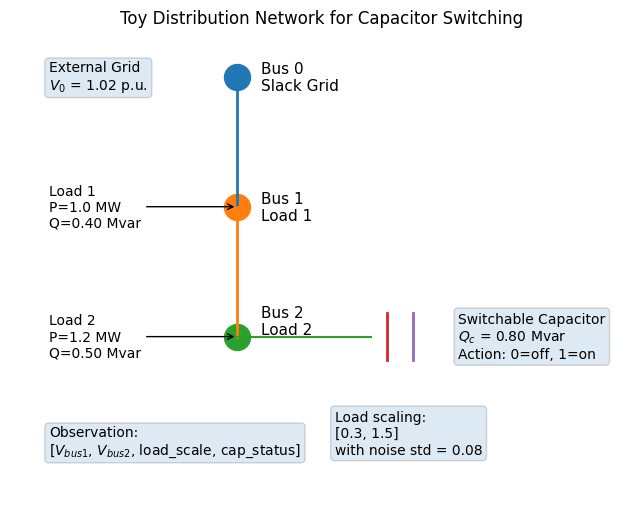

In [7]:
topology_config = EnvConfig()
plot_toy_network_topology(topology_config)

### 3.2 Environment Class

In [8]:
class CapacitorSwitchingEnv(gym.Env):
    """
    一个最小配电网电容器投切环境。

    动作:
        0: 电容器切除
        1: 电容器投入

    状态:
        [bus1电压, bus2电压, 负荷倍率, 电容器状态]

    奖励:
        电压越接近 1.0 p.u. 越好；
        电压越限惩罚更重；
        网损越小越好；
        频繁投切有小惩罚。
    """

    metadata = {"render_modes": []}

    # 注意这里的参数被展开成 self.xxx 的形式了，后续代码中直接使用 self.xxx 来访问这些配置项
    def __init__(self, config: EnvConfig | None = None):
        """初始化环境，构建配电网，定义状态空间和动作空间。"""
        super().__init__()

        if config is None:
            config = EnvConfig()

        self.config = config

        self.episode_len = config.episode_len
        self.t = 0

        self.cap_status = 0
        self.load_scale = 1.0

        self.load_scale_min = config.load_scale_min
        self.load_scale_max = config.load_scale_max
        self.load_noise_std = config.load_noise_std

        self.switch_cost = config.switch_cost
        self.voltage_dev_weight = config.voltage_dev_weight
        self.voltage_violation_weight = config.voltage_violation_weight
        self.loss_weight = config.loss_weight

        self.cap_q_mvar = config.cap_q_mvar
        self.ext_grid_vm_pu = config.ext_grid_vm_pu

        self.net = self._build_network()

        self.observation_space = spaces.Box(
            low=np.array([0.70, 0.70, self.load_scale_min, 0.0], dtype=np.float32),
            high=np.array([1.30, 1.30, self.load_scale_max, 1.0], dtype=np.float32),
            dtype=np.float32
        )

        self.action_space = spaces.Discrete(2)

    def _build_network(self):
        """构建一个简单的三节点配电网，包含一个外部电网、两条线路、两个负荷和一个可控电容器。"""
        net = pp.create_empty_network(sn_mva=10.0)

        b0 = pp.create_bus(net, vn_kv=10.0, name="Slack Bus")
        b1 = pp.create_bus(net, vn_kv=10.0, name="Bus 1")
        b2 = pp.create_bus(net, vn_kv=10.0, name="Bus 2")

        pp.create_ext_grid(net, bus=b0, vm_pu=self.ext_grid_vm_pu, name="Grid")

        # 简化线路参数：为了教学演示，不追求真实线路精度
        pp.create_line_from_parameters(
            net,
            from_bus=b0,
            to_bus=b1,
            length_km=1.0,
            r_ohm_per_km=0.30,
            x_ohm_per_km=0.40,
            c_nf_per_km=0.0,
            max_i_ka=1.0,
            name="Line 0-1"
        )

        pp.create_line_from_parameters(
            net,
            from_bus=b1,
            to_bus=b2,
            length_km=1.0,
            r_ohm_per_km=0.30,
            x_ohm_per_km=0.40,
            c_nf_per_km=0.0,
            max_i_ka=1.0,
            name="Line 1-2"
        )

        # 基准负荷，后续通过 scaling 随机扰动
        pp.create_load(net, bus=b1, p_mw=1.0, q_mvar=0.40, name="Load 1")
        pp.create_load(net, bus=b2, p_mw=1.2, q_mvar=0.50, name="Load 2")

        # 在末端 bus2 接一个并联电容器
        cap_idx = pp.create_shunt_as_capacitor(
            net,
            bus=b2,
            q_mvar=self.cap_q_mvar,
            loss_factor=0.0,
            name="Capacitor Bank",
            in_service=False
        )

        net.cap_idx = cap_idx
        return net

    def _run_power_flow(self):
        """调用 pandapower 计算潮流，更新网络状态。"""
        pp.runpp(
            self.net,
            algorithm="nr",
            init="auto",
            calculate_voltage_angles=False,
            numba=False
        )

    def _reset_random_load(self):
        """在每个 episode 开始时，随机生成一个负荷倍率，并应用到网络中。"""
        self.load_scale = float(
            self.np_random.uniform(self.load_scale_min, self.load_scale_max)
        )
        self.net.load["scaling"] = self.load_scale

    def _advance_random_load(self):
        """在每个 step 结束时，基于当前负荷倍率加上一个小的随机扰动，生成下一时刻的负荷倍率，并应用到网络中。"""
        noise = float(self.np_random.normal(0.0, self.load_noise_std))

        self.load_scale = float(
            np.clip(
                self.load_scale + noise,
                self.load_scale_min,
                self.load_scale_max
            )
        )

        self.net.load["scaling"] = self.load_scale

    def _get_obs(self):
        """获取当前状态观测值，包括两条线路末端的电压、当前负荷倍率和电容器状态。"""
        vm_bus1 = float(self.net.res_bus.vm_pu.iloc[1])
        vm_bus2 = float(self.net.res_bus.vm_pu.iloc[2])

        obs = np.array(
            [vm_bus1, vm_bus2, self.load_scale, float(self.cap_status)],
            dtype=np.float32
        )
        return obs

    def _compute_reward(self, prev_cap_status):
        """计算奖励值。"""
        vm_all = self.net.res_bus.vm_pu.to_numpy(dtype=np.float32)
        # 只评价可控负荷节点 bus1 和 bus2，避免固定 slack bus 电压给 reward 加入不可控常数项。
        vm = vm_all[1:]

        voltage_deviation = np.sum((vm - 1.0) ** 2)

        over_voltage = np.maximum(vm - 1.05, 0.0)
        under_voltage = np.maximum(0.95 - vm, 0.0)
        voltage_violation = np.sum(over_voltage ** 2 + under_voltage ** 2)

        line_loss_mw = float(self.net.res_line.pl_mw.sum())

        switch_penalty = float(abs(self.cap_status - prev_cap_status))

        reward = (
            - self.voltage_dev_weight * voltage_deviation
            - self.voltage_violation_weight * voltage_violation
            - self.loss_weight * line_loss_mw
            - self.switch_cost * switch_penalty
        )

        info = {
            "vm_pu": vm_all,
            "line_loss_mw": line_loss_mw,
            "cap_status": self.cap_status,
            "load_scale": self.load_scale,
            "switch_penalty": switch_penalty,
            "voltage_deviation": float(voltage_deviation),
            "voltage_violation": float(voltage_violation),
            "reward": float(reward),
        }

        return float(reward), info

    def reset(
        self,
        *,
        seed: int | None = None,
        options: dict[str, Any] | None = None
    ) -> tuple[np.ndarray, dict[str, Any]]:
        """重置环境状态，随机生成初始负荷倍率，电容器默认为切除状态，并计算初始潮流。"""
        super().reset(seed=seed)

        self.t = 0
        self.cap_status = 0

        self.net.shunt.at[self.net.cap_idx, "in_service"] = bool(self.cap_status)

        self._reset_random_load()
        self._run_power_flow()

        return self._get_obs(), {}

    def step(
        self,
        action: int
    ) -> tuple[np.ndarray, float, bool, bool, dict[str, Any]]:
        """执行智能体的动作，更新电容器状态，计算潮流，得到奖励，并生成下一时刻的负荷扰动。"""
        action = int(action)
        assert self.action_space.contains(action)

        prev_cap_status = self.cap_status
        self.cap_status = action

        # 在当前负荷下执行电容器动作
        self.net.shunt.at[self.net.cap_idx, "in_service"] = bool(self.cap_status)

        try:
            # 先基于当前负荷计算 reward
            self._run_power_flow()
            reward, info = self._compute_reward(prev_cap_status)

            self.t += 1
            terminated = False
            truncated = self.t >= self.episode_len

            # 再生成下一时刻负荷，作为 next_state
            if not truncated:
                self._advance_random_load()
                self._run_power_flow()

            next_obs = self._get_obs()

            return next_obs, float(reward), terminated, truncated, info

        except pp.LoadflowNotConverged:
            obs = np.array(
                [0.70, 0.70, self.load_scale, float(self.cap_status)],
                dtype=np.float32
            )
            reward = -100.0
            terminated = True
            truncated = False
            info = {"loadflow_converged": False}
            return obs, reward, terminated, truncated, info

## 4. Environment Sanity Checks

### 4.1 reset check

In [9]:
# reset 测试
env_config = EnvConfig()
test_env = CapacitorSwitchingEnv(config=env_config)
"""最后一维 cap_status 是否固定为 0 
load_scale 是否在设定范围内 
obs 是否落在 observation_space 内"""

for seed in range(10):
    obs, info = test_env.reset(seed=seed)
    print(seed, obs)
    assert test_env.observation_space.contains(obs)

test_env.close()

0 [1.0091748 1.0032276 1.0643541 0.       ]
1 [1.0107248  1.0056295  0.91418594 0.        ]
2 [1.0138011 1.0103964 0.6139346 0.       ]
3 [1.0159467 1.0137209 0.402779  0.       ]
4 [1.0053511 0.9973009 1.4316673 0.       ]
5 [1.0070815 0.9999831 1.2660035 0.       ]
6 [1.0103991 1.0051249 0.9457972 0.       ]
7 [1.0093222 1.0034559 1.0501145 0.       ]
8 [1.0130004 1.0091558 0.6923667 0.       ]
9 [1.0062649  0.99871737 1.3442991  0.        ]


### 4.2 smoke test

In [10]:
# 冒烟测试
def smoke_test_env(env, seed=0, n_steps=None):
    '''对环境接口进行冒烟测试，验证基本的 reset 和 step 功能是否正常。'''
    env.action_space.seed(seed)

    obs, info = env.reset(seed=seed)
    print("initial obs:", obs)

    assert env.observation_space.contains(obs), (
        f"Initial obs is outside observation_space: {obs}"
    )

    total_reward = 0.0
    n_steps = n_steps or env.episode_len

    for k in range(n_steps):
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)

        reward = float(reward)
        total_reward += reward

        assert env.observation_space.contains(obs), (
            f"Obs at step {k} is outside observation_space: {obs}"
        )
        assert np.isfinite(reward), f"Reward at step {k} is not finite: {reward}"

        print(
            k,
            "action =", action,
            "obs =", obs,
            "reward =", reward,
            "cap =", info.get("cap_status"),
            "loss =", info.get("line_loss_mw"),
            "switch =", info.get("switch_penalty"),
        )

        if terminated or truncated:
            print("episode ended at step", k)
            break

    print("total reward:", total_reward)

In [11]:
sanity_env_config = EnvConfig()
cap_env = CapacitorSwitchingEnv(config=sanity_env_config)

smoke_test_env(cap_env, seed=0)

cap_env.close()

initial obs: [1.0091748 1.0032276 1.0643541 0.       ]
0 action = 1 obs = [1.0125293 1.0099006 1.0537857 1.       ] reward = -0.028197146952152252 cap = 1 loss = 0.02121843783850008 switch = 1.0
1 action = 1 obs = [1.0119975 1.009076  1.1050195 1.       ] reward = -0.025900593027472496 cap = 1 loss = 0.020800523341153898 switch = 0.0
2 action = 1 obs = [1.0119102 1.0089408 1.1134114 1.       ] reward = -0.027400489896535873 cap = 1 loss = 0.022874231485574104 switch = 0.0
3 action = 0 obs = [1.0091107 1.003128  1.070558  0.       ] reward = -0.030669108033180237 cap = 0 loss = 0.027047708818739302 switch = 1.0
4 action = 0 obs = [1.0088111 1.002664  1.0994855 0.       ] reward = -0.026831522583961487 cap = 0 loss = 0.024975735433543367 switch = 0.0
5 action = 0 obs = [1.0077287 1.0009862 1.2038056 0.       ] reward = -0.0280597023665905 cap = 0 loss = 0.026365053487462875 switch = 0.0
6 action = 0 obs = [1.0069401  0.99976397 1.279572   0.        ] reward = -0.03291230648756027 cap = 0

### 4.3 one-step reward scan

In [12]:
def evaluate_one_step_reward(env, load_scale, action, cap_status_before=0):
    """评估在给定负荷倍率和电容器初始状态下，执行一个动作后的单步奖励。"""

    load_scale = float(load_scale)
    action = int(action)
    cap_status_before = int(cap_status_before)

    assert env.action_space.contains(action)

    # 1. 设置当前负荷
    env.load_scale = load_scale
    env.net.load["scaling"] = env.load_scale

    # 2. 先设置动作执行前的电容器状态
    env.cap_status = cap_status_before
    env.net.shunt.at[env.net.cap_idx, "in_service"] = bool(env.cap_status)

    # 3. 执行动作：把电容器切换到 action 对应的目标状态
    prev_cap_status = env.cap_status
    env.cap_status = action
    env.net.shunt.at[env.net.cap_idx, "in_service"] = bool(env.cap_status)

    try:
        env._run_power_flow()
        reward, info = env._compute_reward(prev_cap_status)
        vm = info["vm_pu"]

        return reward, info, vm

    except pp.LoadflowNotConverged:
        return -100.0, {"loadflow_converged": False}, np.array([np.nan])

In [13]:
scan_env = CapacitorSwitchingEnv(config=env_config) # 扫描评估不同负荷倍率和动作组合下的奖励情况

for cap_before in [0, 1]:
    print(f"\ncap_status_before = {cap_before}")

    for ls in np.linspace(
        env_config.load_scale_min,
        env_config.load_scale_max,
        13
    ):
        r_off, info_off, vm_off = evaluate_one_step_reward(
            scan_env,
            load_scale=ls,
            action=0,
            cap_status_before=cap_before
        )

        r_on, info_on, vm_on = evaluate_one_step_reward(
            scan_env,
            load_scale=ls,
            action=1,
            cap_status_before=cap_before
        )

        best_action = 0 if r_off >= r_on else 1

        print(
            f"load={ls:.2f} | "
            f"r_off={r_off:.4f}, v2_off={vm_off[2]:.4f} | "
            f"r_on={r_on:.4f}, v2_on={vm_on[2]:.4f} | "
            f"best={best_action}"
        )


cap_status_before = 0
load=0.30 | r_off=-0.0124, v2_off=1.0153 | r_on=-0.0237, v2_on=1.0219 | best=0
load=0.40 | r_off=-0.0123, v2_off=1.0138 | r_on=-0.0223, v2_on=1.0203 | best=0
load=0.50 | r_off=-0.0128, v2_off=1.0122 | r_on=-0.0216, v2_on=1.0187 | best=0
load=0.60 | r_off=-0.0139, v2_off=1.0106 | r_on=-0.0214, v2_on=1.0171 | best=0
load=0.70 | r_off=-0.0155, v2_off=1.0090 | r_on=-0.0218, v2_on=1.0156 | best=0
load=0.80 | r_off=-0.0178, v2_off=1.0074 | r_on=-0.0228, v2_on=1.0140 | best=0
load=0.90 | r_off=-0.0206, v2_off=1.0059 | r_on=-0.0243, v2_on=1.0124 | best=0
load=1.00 | r_off=-0.0240, v2_off=1.0043 | r_on=-0.0265, v2_on=1.0108 | best=0
load=1.10 | r_off=-0.0281, v2_off=1.0027 | r_on=-0.0292, v2_on=1.0092 | best=0
load=1.20 | r_off=-0.0327, v2_off=1.0010 | r_on=-0.0326, v2_on=1.0075 | best=1
load=1.30 | r_off=-0.0380, v2_off=0.9994 | r_on=-0.0366, v2_on=1.0059 | best=1
load=1.40 | r_off=-0.0439, v2_off=0.9978 | r_on=-0.0411, v2_on=1.0043 | best=1
load=1.50 | r_off=-0.0504, v2

## 5. Evaluation Utilities

### 5.1 evaluate_agent

In [14]:
def evaluate_agent(env, agent, n_episodes=10, seed=6000):
    """在 epsilon=0 的贪婪策略下评估智能体。"""
    returns = []

    old_epsilon = agent.epsilon
    agent.epsilon = 0.0

    try:
        for ep in range(n_episodes):
            obs, info = env.reset(seed=seed + ep)
            done = False
            episode_return = 0.0

            while not done:
                action = agent.take_action(obs)

                obs, reward, terminated, truncated, info = env.step(action)
                done = terminated or truncated

                episode_return += float(reward)

            returns.append(episode_return)

    finally:
        agent.epsilon = old_epsilon

    return returns

## 6. DQN Training

### 6.1 Create Configs, Environments and Agent

In [15]:
# 创建配置
train_config = TrainConfig()
env_config = EnvConfig()

# 设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 环境
env_name = "CapacitorSwitchingEnv"
env = CapacitorSwitchingEnv(config=env_config)
eval_env = CapacitorSwitchingEnv(config=env_config)

# 随机种子
random.seed(train_config.seed)
np.random.seed(train_config.seed)
torch.manual_seed(train_config.seed)
if device.type == "cuda":
    torch.cuda.manual_seed(train_config.seed)

# 状态维度和动作维度

assert isinstance(env.observation_space, Box)
state_dim = env.observation_space.shape[0]

assert isinstance(env.action_space, Discrete)
action_dim = env.action_space.n

# replay buffer
replay_buffer = ReplayBuffer(capacity=train_config.buffer_size)

# DQN agent
agent = DQN(
    state_dim=state_dim,
    hidden_dim=train_config.hidden_dim,
    action_dim=action_dim,
    learning_rate=train_config.lr,
    gamma=train_config.gamma,
    epsilon=train_config.epsilon,
    target_update=train_config.target_update,
    device=device
)

### 6.2 Initialize Training Logs

In [16]:
# 训练记录
return_list = []

eval_episode_list = []
eval_mean_return_list = []
eval_std_return_list = []

# 最佳模型记录
best_mean_return = -float("inf")
best_episode = 0
best_q_net_state = None
best_model_path = "best_dqn_capacitor_switching.pth"

### 6.3 Run Training Loop

In [17]:
for i in range(10):
    with tqdm(total=train_config.num_episodes // 10, desc=f"Iteration {i}") as pbar:
        for i_episode in range(train_config.num_episodes // 10):
            episode_return = 0.0

            state, info = env.reset(
                seed=train_config.seed + i * 100 + i_episode
            )

            done = False

            while not done:
                action = agent.take_action(state)

                next_state, reward, terminated, truncated, info = env.step(action)
                reward = float(reward)
                done = terminated or truncated

                replay_buffer.add(state, action, reward, next_state, done)

                state = next_state
                episode_return += reward

                if len(replay_buffer) > train_config.minimal_size:
                    transition_dict = replay_buffer.sample(train_config.batch_size)
                    agent.update(transition_dict)

            return_list.append(episode_return)

            if (i_episode + 1) % 10 == 0:
                mean_return = np.mean(return_list[-10:])
                pbar.set_postfix({
                    "episode": f"{train_config.num_episodes // 10 * i + i_episode + 1}",
                    "return": f"{mean_return:.3f}"
                })

            pbar.update(1)

    current_episode = (i + 1) * (train_config.num_episodes // 10)

    test_returns = evaluate_agent(
        eval_env,
        agent,
        n_episodes=10,
        seed=6000
    )

    mean_test_return = np.mean(test_returns)
    std_test_return = np.std(test_returns)

    print("test returns:", test_returns)
    print("mean return:", mean_test_return)

    eval_episode_list.append(current_episode)
    eval_mean_return_list.append(mean_test_return)
    eval_std_return_list.append(std_test_return)

    if mean_test_return > best_mean_return:
        best_mean_return = mean_test_return
        best_episode = current_episode
        best_q_net_state = copy.deepcopy(agent.q_net.state_dict())
        torch.save(best_q_net_state, best_model_path)

        print(
            f"New best model saved at episode {best_episode}, "
            f"mean return = {best_mean_return:.3f}"
        )

Iteration 0: 100%|██████████| 30/30 [00:47<00:00,  1.60s/it, episode=30, return=-0.272]


test returns: [-0.3624766319990158, -0.329476548358798, -0.3821146674454212, -0.1489092344418168, -0.2012334931641817, -0.35627848096191883, -0.38828562945127487, -0.47887590527534485, -0.25972953625023365, -0.21979239955544472]
mean return: -0.31271725269034506
New best model saved at episode 30, mean return = -0.313


Iteration 1: 100%|██████████| 30/30 [00:44<00:00,  1.47s/it, episode=60, return=-0.324]


test returns: [-0.36255960538983345, -0.329476548358798, -0.38405079767107964, -0.1489092344418168, -0.17814978677779436, -0.3573461268097162, -0.3897257335484028, -0.47887590527534485, -0.22872078604996204, -0.19528109766542912]
mean return: -0.3053095621988177
New best model saved at episode 60, mean return = -0.305


Iteration 2: 100%|██████████| 30/30 [00:59<00:00,  1.98s/it, episode=90, return=-0.341]


...

test returns: [-0.3624766319990158, -0.329476548358798, -0.3821146674454212, -0.2528775278478861, -0.24130990356206894, -0.35627848096191883, -0.38828562945127487, -0.47887590527534485, -0.25972953625023365, -0.24458399787545204]
mean return: -0.3296008829027414


Iteration 8: 100%|██████████| 30/30 [00:37<00:00,  1.26s/it, episode=270, return=-0.303]


test returns: [-0.36255960538983345, -0.329476548358798, -0.3821146674454212, -0.1489092344418168, -0.17814978677779436, -0.35627848096191883, -0.38828562945127487, -0.47887590527534485, -0.22872078604996204, -0.19528109766542912]
mean return: -0.30486517418175935


Iteration 9: 100%|██████████| 30/30 [00:38<00:00,  1.27s/it, episode=300, return=-0.328]


test returns: [-0.3648047633469105, -0.329476548358798, -0.3859018087387085, -0.1489092344418168, -0.17814978677779436, -0.3631743025034666, -0.3897257335484028, -0.47887590527534485, -0.22872078604996204, -0.19528109766542912]
mean return: -0.3063019966706634


### 6.4 Restore Best Model

In [18]:
if best_q_net_state is not None:
    agent.q_net.load_state_dict(best_q_net_state)
    agent.target_q_net.load_state_dict(best_q_net_state)

    final_returns = evaluate_agent(
        eval_env,
        agent,
        n_episodes=10,
        seed=6000
    )

    print("restored best returns:", final_returns)
    print("restored best mean:", np.mean(final_returns))
else:
    print("No best model was saved.")

restored best returns: [-0.3624766319990158, -0.329476548358798, -0.3821146674454212, -0.1489092344418168, -0.17814978677779436, -0.35627848096191883, -0.38828562945127487, -0.47887590527534485, -0.22872078604996204, -0.19528109766542912]
restored best mean: -0.3048568768426776


## 7. Benchmark and Paired Comparison

### 7.1 baseline policy

In [19]:
# 评估基准策略的表现，作为 DQN 智能体的对照组，分别评估以下三种基准策略：
# - 随机策略：每一步随机采样动作。
# - 固定策略：始终执行动作0（切除）或动作1（投入）。
# - 规则策略：基于负荷水平的滞环规则，负荷高于1.20时投入，低于0.90时切除。
def evaluate_fixed_policy(env, fixed_action, n_episodes=20, seed=6000):
    """固定执行 0 或 1，评估该动作的表现。"""
    fixed_action = int(fixed_action)
    assert env.action_space.contains(fixed_action)

    returns = []

    for ep in range(n_episodes):
        obs, info = env.reset(seed=seed + ep)
        done = False
        episode_return = 0.0

        while not done:
            obs, reward, terminated, truncated, info = env.step(fixed_action)
            done = terminated or truncated
            episode_return += float(reward)

        returns.append(episode_return)

    return returns


def evaluate_random_policy(env, n_episodes=20, seed=6000, action_seed=7000):
    """每一步随机采样动作，评估随机策略的表现。"""
    returns = []

    env.action_space.seed(action_seed)

    for ep in range(n_episodes):
        obs, info = env.reset(seed=seed + ep)
        done = False
        episode_return = 0.0

        while not done:
            action = env.action_space.sample()
            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            episode_return += float(reward)

        returns.append(episode_return)

    return returns


def evaluate_rule_policy(
    env,
    n_episodes=20,
    seed=6000,
    turn_on_threshold=1.20,
    turn_off_threshold=0.90
):
    """滞环规则策略：高负荷时投入，低负荷时切除。"""
    returns = []

    for ep in range(n_episodes):
        obs, info = env.reset(seed=seed + ep)
        done = False
        episode_return = 0.0

        while not done:
            load_scale = float(obs[2])
            cap_status = int(obs[-1])

            if cap_status == 0:
                action = 1 if load_scale > turn_on_threshold else 0
            else:
                action = 0 if load_scale < turn_off_threshold else 1

            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            episode_return += float(reward)

        returns.append(episode_return)

    return returns

### 7.2 run_benchmark

In [20]:
def run_benchmark(
    agent,
    env_config,
    benchmark_seed=8000,
    n_benchmark_episodes=100
):
    random_returns = evaluate_random_policy(
        CapacitorSwitchingEnv(config=env_config),
        n_episodes=n_benchmark_episodes,
        seed=benchmark_seed,
        action_seed=benchmark_seed + 10000
    )

    always_off_returns = evaluate_fixed_policy(
        CapacitorSwitchingEnv(config=env_config),
        fixed_action=0,
        n_episodes=n_benchmark_episodes,
        seed=benchmark_seed
    )

    always_on_returns = evaluate_fixed_policy(
        CapacitorSwitchingEnv(config=env_config),
        fixed_action=1,
        n_episodes=n_benchmark_episodes,
        seed=benchmark_seed
    )

    rule_returns = evaluate_rule_policy(
        CapacitorSwitchingEnv(config=env_config),
        n_episodes=n_benchmark_episodes,
        seed=benchmark_seed
    )

    dqn_returns = evaluate_agent(
        CapacitorSwitchingEnv(config=env_config),
        agent,
        n_episodes=n_benchmark_episodes,
        seed=benchmark_seed
    )

    returns_dict = {
        "Random": random_returns,
        "Always Off": always_off_returns,
        "Always On": always_on_returns,
        "Rule": rule_returns,
        "DQN": dqn_returns,
    }

    benchmark_results = [
        (name, np.mean(returns), np.std(returns))
        for name, returns in returns_dict.items()
    ]

    benchmark_results = sorted(
        benchmark_results,
        key=lambda x: x[1],
        reverse=True
    )

    print(f"{'Rank':<6}{'Policy':<14}{'Mean Return':>14}{'Std Return':>14}")
    for rank, (policy, mean_ret, std_ret) in enumerate(benchmark_results, start=1):
        print(f"{rank:<6}{policy:<14}{mean_ret:>14.6f}{std_ret:>14.6f}")

    return benchmark_results, returns_dict

In [21]:
benchmark_results, returns_dict = run_benchmark(
    agent,
    env_config=env_config,
    benchmark_seed=8000,
    n_benchmark_episodes=100
)

Rank  Policy           Mean Return    Std Return
1     Rule               -0.281208      0.117977
2     DQN                -0.282313      0.117226
3     Always Off         -0.294136      0.137320
4     Random             -0.316075      0.112327
5     Always On          -0.316141      0.087590


### 7.3 paired_compare

In [22]:
def paired_compare(name_a, returns_a, name_b, returns_b):
    """对比两组 returns，统计 A 相对 B 的平均差值、差值标准差以及胜平负比例。"""
    a = np.asarray(returns_a, dtype=np.float32)
    b = np.asarray(returns_b, dtype=np.float32)

    assert len(a) == len(b), "returns_a 和 returns_b 的长度必须一致。"

    diff = a - b

    print(f"{name_a} vs {name_b}")
    print(f"  mean({name_a} - {name_b}) = {np.mean(diff):.6f}")
    print(f"  std diff                 = {np.std(diff):.6f}")
    print(f"  win rate                 = {np.mean(diff > 0):.3f}")
    print(f"  tie rate                 = {np.mean(diff == 0):.3f}")
    print(f"  lose rate                = {np.mean(diff < 0):.3f}")
    print()

In [23]:
# 对比 DQN 与其他策略的性能
paired_compare("DQN", returns_dict["DQN"], "Rule", returns_dict["Rule"])
paired_compare("DQN", returns_dict["DQN"], "Always Off", returns_dict["Always Off"])
paired_compare("DQN", returns_dict["DQN"], "Always On", returns_dict["Always On"])
paired_compare("DQN", returns_dict["DQN"], "Random", returns_dict["Random"])

DQN vs Rule
  mean(DQN - Rule) = -0.001106
  std diff                 = 0.005915
  win rate                 = 0.200
  tie rate                 = 0.650
  lose rate                = 0.150

DQN vs Always Off
  mean(DQN - Always Off) = 0.011823
  std diff                 = 0.022990
  win rate                 = 0.410
  tie rate                 = 0.450
  lose rate                = 0.140

DQN vs Always On
  mean(DQN - Always On) = 0.033828
  std diff                 = 0.037717
  win rate                 = 0.620
  tie rate                 = 0.380
  lose rate                = 0.000

DQN vs Random
  mean(DQN - Random) = 0.033762
  std diff                 = 0.019373
  win rate                 = 0.970
  tie rate                 = 0.000
  lose rate                = 0.030



## 8. Policy Diagnostics

### 8.1 Action Counts

In [24]:
def evaluate_agent_with_actions(env, agent, n_episodes=20, seed=8000):
    """评估智能体在环境中的表现，并统计每个动作的执行次数。"""
    returns = []

    assert isinstance(env.action_space, Discrete)
    action_counts = {a: 0 for a in range(env.action_space.n)}

    old_epsilon = agent.epsilon
    agent.epsilon = 0.0

    try:
        for ep in range(n_episodes):
            obs, info = env.reset(seed=seed + ep)
            done = False
            episode_return = 0.0

            while not done:
                action = int(agent.take_action(obs))
                action_counts[action] += 1

                obs, reward, terminated, truncated, info = env.step(action)
                done = terminated or truncated
                episode_return += float(reward)

            returns.append(episode_return)

    finally:
        agent.epsilon = old_epsilon

    return returns, action_counts

In [25]:
diag_env = CapacitorSwitchingEnv(config=env_config)

dqn_action_returns, dqn_action_counts = evaluate_agent_with_actions(
    diag_env,
    agent,
    n_episodes=100,
    seed=8000
)

diag_env.close()

print("DQN mean return:", np.mean(dqn_action_returns))
print("DQN action counts:", dqn_action_counts)

total_actions = sum(dqn_action_counts.values())
for action, count in dqn_action_counts.items():
    print(f"action {action}: {count} times, ratio = {count / total_actions:.3f}")

DQN mean return: -0.28231310409493743
DQN action counts: {0: 607, 1: 593}
action 0: 607 times, ratio = 0.506
action 1: 593 times, ratio = 0.494



### 8.2 Transition Counts

In [26]:
def collect_dqn_policy_records(env, agent, n_episodes=100, seed=8000):
    """收集智能体在环境中执行的详细记录，包括状态、动作、奖励和电容器状态切换情况。"""
    records = []

    old_epsilon = agent.epsilon
    agent.epsilon = 0.0

    try:
        for ep in range(n_episodes):
            obs, info = env.reset(seed=seed + ep)
            done = False

            while not done:
                v_bus1 = float(obs[0])
                v_bus2 = float(obs[1])
                load_scale = float(obs[2])
                cap_status_before = int(obs[3])

                action = int(agent.take_action(obs))

                next_obs, reward, terminated, truncated, info = env.step(action)
                done = terminated or truncated

                records.append({
                    "v_bus1": v_bus1,
                    "v_bus2": v_bus2,
                    "load_scale": load_scale,
                    "cap_status_before": cap_status_before,
                    "action": action,
                    "switched": int(action != cap_status_before),
                    "reward": float(reward),
                    "cap_status_after": int(info["cap_status"]),
                })

                obs = next_obs

    finally:
        agent.epsilon = old_epsilon

    return records

In [27]:
diag_env = CapacitorSwitchingEnv(config=env_config)

records = collect_dqn_policy_records(
    diag_env,
    agent,
    n_episodes=100,
    seed=8000
)

diag_env.close()

transition_counts = Counter(
    (r["cap_status_before"], r["action"]) for r in records
)

print("Transition counts:")
print("(before_status, action) -> count")
for k, v in sorted(transition_counts.items()):
    print(k, "->", v)

switch_count = sum(r["switched"] for r in records)
total_steps = len(records)

print("switch count:", switch_count)
print("total steps:", total_steps)
print("switch ratio:", switch_count / total_steps)

Transition counts:
(before_status, action) -> count
(0, 0) -> 603
(0, 1) -> 55
(1, 0) -> 4
(1, 1) -> 538
switch count: 59
total steps: 1200
switch ratio: 0.049166666666666664


### 8.3 State-Action Statistics

In [28]:
def summarize_records(records):
    """按动作分组，统计每个动作对应的平均负荷倍率、平均 bus2 电压和平均奖励。"""
    actions = sorted(set(r["action"] for r in records))

    for action in actions:
        subset = [r for r in records if r["action"] == action]

        if not subset:
            print(f"action {action}: no records")
            continue

        mean_load = np.mean([r["load_scale"] for r in subset])
        mean_v2 = np.mean([r["v_bus2"] for r in subset])
        mean_reward = np.mean([r["reward"] for r in subset])

        print(
            f"action {action}: "
            f"count={len(subset)}, "
            f"mean_load={mean_load:.3f}, "
            f"mean_v_bus2={mean_v2:.4f}, "
            f"mean_reward={mean_reward:.4f}"
        )

In [29]:
summarize_records(records) 

action 0: count=607, mean_load=0.606, mean_v_bus2=1.0106, mean_reward=-0.0150
action 1: count=593, mean_load=1.204, mean_v_bus2=1.0069, mean_reward=-0.0322


## 9. Visualization

### 9.1 Benchmark Bar Chart

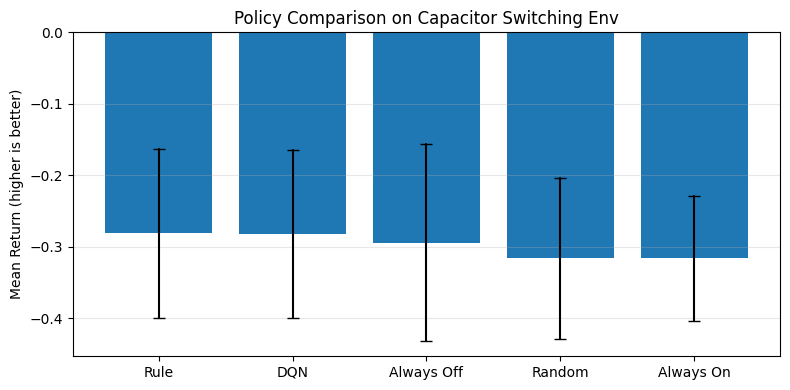

In [30]:
assert "benchmark_results" in globals(), "请先运行第 7.2 节 run_benchmark。"

policies = [x[0] for x in benchmark_results]
mean_returns = [x[1] for x in benchmark_results]
std_returns = [x[2] for x in benchmark_results]

plt.figure(figsize=(8, 4))
plt.bar(policies, mean_returns, yerr=std_returns, capsize=4)

plt.ylabel("Mean Return (higher is better)")
plt.title("Policy Comparison on Capacitor Switching Env")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 9.2 Training vs Evaluation Curve

In [31]:
# 检查评估结果的变量是否存在，确保之前的代码块已经正确运行并生成了这些变量。
required_vars = [
    "return_list",
    "eval_episode_list",
    "eval_mean_return_list",
    "eval_std_return_list",
]

for var in required_vars:
    assert var in globals(), f"请先运行训练部分，缺少变量: {var}"

In [32]:
def moving_average(x, window_size=9):
    """因果滑动平均：第 i 点使用其之前若干点的平均值。"""
    x = np.asarray(x, dtype=np.float32)
    y = np.zeros_like(x)

    for i in range(len(x)):
        start = max(0, i - window_size + 1)
        y[i] = np.mean(x[start:i + 1])

    return y

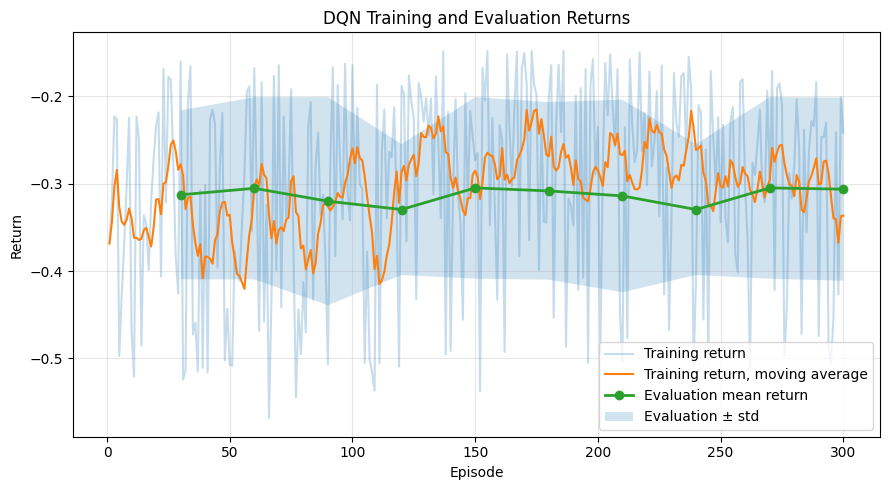

In [33]:
episodes = np.arange(1, len(return_list) + 1)

train_returns = np.asarray(return_list, dtype=np.float32)
train_returns_ma = moving_average(train_returns, window_size=9)

eval_episodes = np.asarray(eval_episode_list)
eval_mean_returns = np.asarray(eval_mean_return_list)
eval_std_returns = np.asarray(eval_std_return_list)

plt.figure(figsize=(9, 5))

plt.plot(
    episodes,
    train_returns,
    alpha=0.25,
    label="Training return"
)

plt.plot(
    episodes,
    train_returns_ma,
    label="Training return, moving average"
)

plt.plot(
    eval_episodes,
    eval_mean_returns,
    marker="o",
    linewidth=2,
    label="Evaluation mean return"
)

plt.fill_between(
    eval_episodes,
    eval_mean_returns - eval_std_returns,
    eval_mean_returns + eval_std_returns,
    alpha=0.2,
    label="Evaluation ± std"
)

plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("DQN Training and Evaluation Returns")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 9.3 Rollout Timeline

In [34]:
def rollout_episode(env, agent, seed=8000):
    """在 env 中执行一个 episode，记录每一步的状态、动作、奖励和信息。"""
    records = []

    old_epsilon = agent.epsilon
    agent.epsilon = 0.0  # 测试时用贪心策略

    try:
        obs, info = env.reset(seed=seed)
        done = False
        t = 0

        while not done:
            v_bus1 = float(obs[0])
            v_bus2 = float(obs[1])
            load_scale = float(obs[2])
            cap_before = int(obs[3])

            action = int(agent.take_action(obs))

            next_obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            records.append({
                "t": t,
                "load_scale": load_scale,
                "v_bus1": v_bus1,
                "v_bus2": v_bus2,
                "cap_before": cap_before,
                "action": action,
                "reward": float(reward),
                "cap_after": int(info["cap_status"]),
                "line_loss_mw": float(info["line_loss_mw"]),
            })

            obs = next_obs
            t += 1

    finally:
        agent.epsilon = old_epsilon

    return records

In [35]:
def plot_episode_rollout(records, title="DQN Rollout on Capacitor Switching Env"):
    """根据 rollout records 绘制负荷、电压、动作和 reward 曲线。"""
    t = [r["t"] for r in records]
    load_scale = [r["load_scale"] for r in records]
    v_bus2 = [r["v_bus2"] for r in records]
    cap_before = [r["cap_before"] for r in records]
    action = [r["action"] for r in records]
    reward = [r["reward"] for r in records]

    plt.figure(figsize=(10, 10))

    plt.subplot(4, 1, 1)
    plt.plot(t, load_scale, marker="o")
    plt.ylabel("load_scale")
    plt.title(title)
    plt.grid(True, alpha=0.3)

    plt.subplot(4, 1, 2)
    plt.plot(t, v_bus2, marker="o")
    plt.axhline(1.0, linestyle="--")
    plt.axhline(0.95, linestyle=":")
    plt.axhline(1.05, linestyle=":")
    plt.ylabel("v_bus2")
    plt.grid(True, alpha=0.3)

    plt.subplot(4, 1, 3)
    plt.step(t, cap_before, where="post", label="cap_before")
    plt.step(t, action, where="post", label="action")
    plt.ylabel("0=off, 1=on")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(4, 1, 4)
    plt.bar(t, reward)
    plt.xlabel("time step")
    plt.ylabel("reward")
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

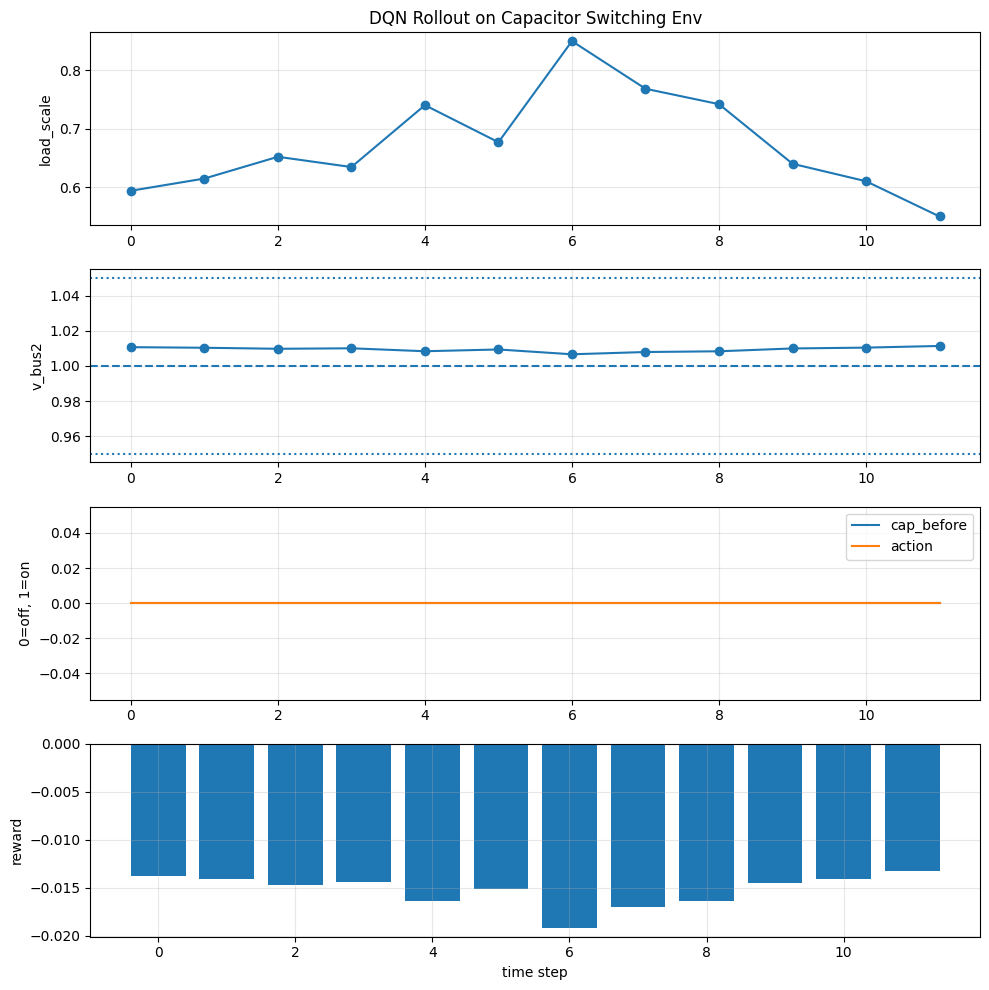

In [36]:
diag_env = CapacitorSwitchingEnv(config=env_config)

rollout_records = rollout_episode(
    diag_env,
    agent,
    seed=8000
)

plot_episode_rollout(
    rollout_records,
    title="DQN Rollout on Capacitor Switching Env"
)

diag_env.close()

found switching seed: 8003


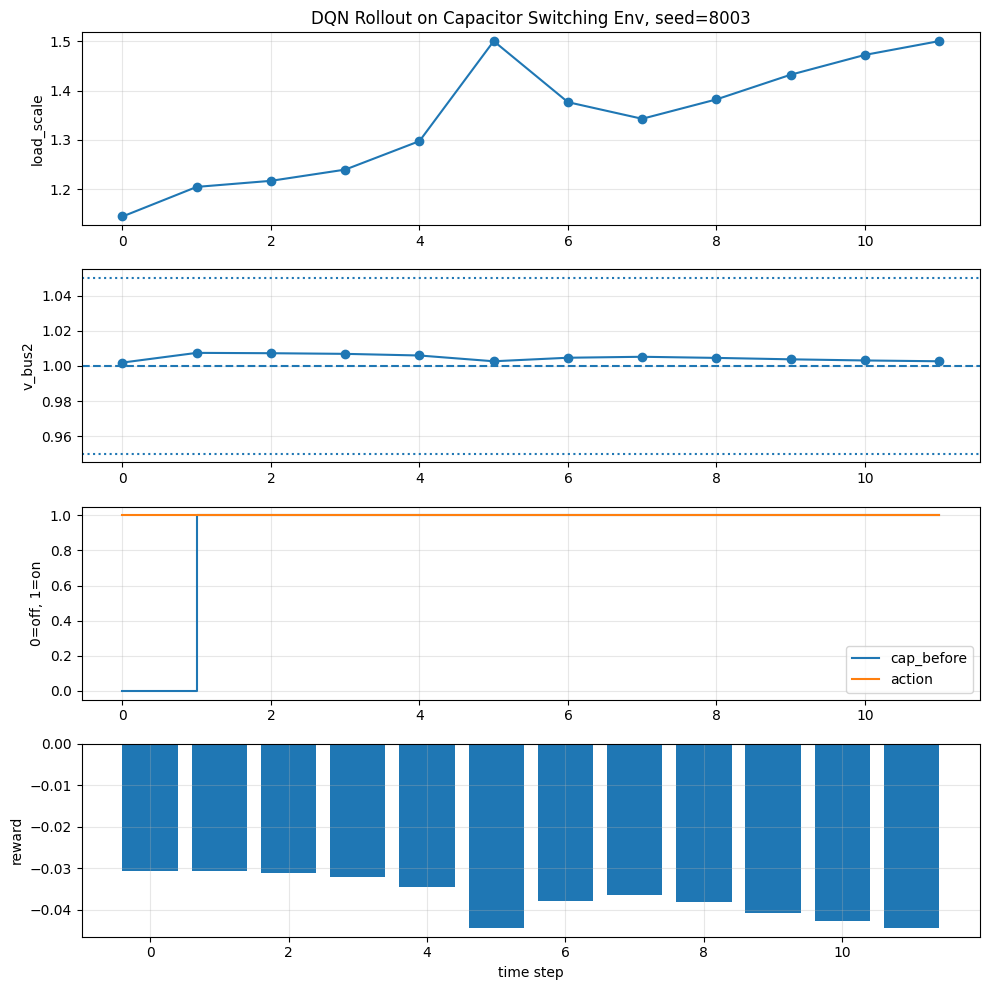

In [37]:
# 如果在上面的 rollout 中没有看到智能体执行切换动作（action=1），我们可以扫描更多的随机种子，
# 看看是否能找到一个包含切换动作的 episode，以便更好地展示智能体的决策行为。
for seed in range(8000, 8050):
    diag_env = CapacitorSwitchingEnv(config=env_config)
    rollout_records = rollout_episode(diag_env, agent, seed=seed)
    diag_env.close()

    actions = [r["action"] for r in rollout_records]
    if 1 in actions:
        print("found switching seed:", seed)
        plot_episode_rollout(
            rollout_records,
            title=f"DQN Rollout on Capacitor Switching Env, seed={seed}"
        )
        break

## 10.conclusion

由于该三节点系统结构简单、可控设备数量少，负荷水平与最优投切动作之间存在较清晰的阈值关系，因此基于负荷滞环的规则策略已经具有很强表现。DQN 在该环境中能够学习到与规则策略几乎一致的投切规律，明显优于随机策略和始终投入策略；相比始终切除策略有一定平均优势，但差距较小，不能说显著胜出。整体来看，DQN 未能显著超过手工规则。后续若扩展到多节点、多电容器或标准配电网测试系统，状态维度和控制耦合增强，DQN 相比简单规则策略的优势可能更容易体现。